In [24]:
all = [var for var in globals() if var[0] != "_"]
for var in all:
    del globals()[var]

del var, all
# This script clears all global variables except those starting with an underscore.

In [25]:
# Modeule imports
import numpy as np
import jax
import jax.numpy as jnp
import torch

import scipy.optimize as sci_opt
from scipy.optimize import NonlinearConstraint
import scipy.special
import module_opt_AD as my_opt

import matplotlib.pyplot as plt

import heat_equation_2D_for_students
import heat_equation_2D_for_students_jax

import importlib
importlib.reload(my_opt)
importlib.reload(heat_equation_2D_for_students)
importlib.reload(heat_equation_2D_for_students_jax)

from heat_equation_2D_for_students import HeatEquation2D
from heat_equation_2D_for_students_jax import HeatEquation2D_JAX

## Initial Solve Test

In [ ]:
lx = .04  # length in x direction
ly = .04  # length in y direction
z = .04  # height of the domain
N = 25    # number of grid points in x, y direction
k_Si = 149  # thermal conductivity of silicon
rho_Si = 2323  # density of silicon
cp_Si = 704.611  # specific heat capacity of silicon
CFL = .1 # CFL number

def T0(x:np.ndarray, y:np.ndarray) -> np.ndarray:
    """
    Initial temperature distribution over the domain.
    """
    T_0 = np.zeros_like(x)
    ## Cosine Case
    T_0 = 70 * np.sin(x * np.pi / lx) * np.sin(y * np.pi / ly) + 293
    return T_0

heq_init = HeatEquation2D(x=lx, y=ly, height=z, n_x=N, n_y=N, k=k_Si, rho=rho_Si, cp=cp_Si, init_condition=T0)

In [305]:
def q_gen(x:np.ndarray, y:np.ndarray, a:np.float64, b:np.float64, c:np.float64) -> np.ndarray:
    """
    Heat generation function over the domain.
    """
    q = a*x + b*y + c
    return q

In [ ]:
a0 = 1e5
b0 = 1e5
c0 = (1.5625*10**5 - 0.02*b0 - 0.02*a0)  # same formula as before

# a0 = 1.5625*10**5
# b0 = 1*10**6*0.0
# c0 = 1*10**6*0.0
heq_init.set_heat_generation(q_gen, a=a0, b=b0, c=c0)  # set heat generation function with design variables

In [ ]:
v0 = 10.0
heq_init.set_fan_velocity(v=v0)  # set fan velocity

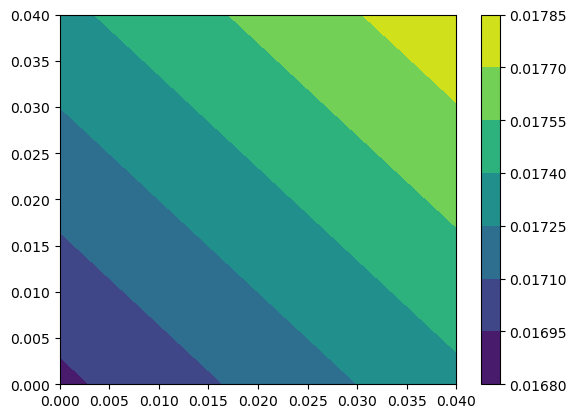

In [308]:
 ## plotting initial conditions
fig, ax = plt.subplots()
contour1 = ax.contourf(heq_init.X, heq_init.Y, q_gen(heq_init.X, heq_init.Y, a0, b0, c0)*heq_init.dx*heq_init.dy*heq_init.height)
fig.colorbar(contour1,ax=ax)
plt.show()

In [309]:
heq_init.heat_generation_total

np.float64(10.190972222222225)

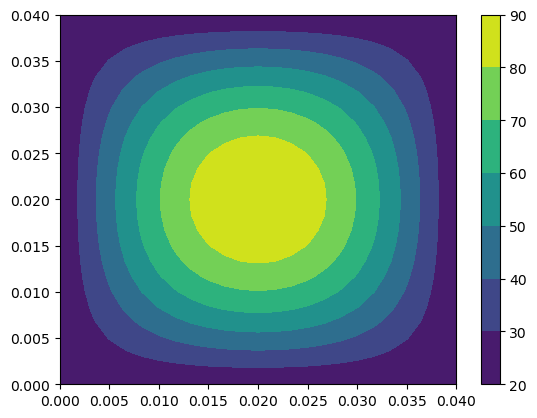

In [310]:
# plotting initial conditions T0
fig, ax = plt.subplots()
contour1 = ax.contourf(heq_init.X, heq_init.Y, heq_init.u - 273)
fig.colorbar(contour1, ax=ax)
plt.show()

In [311]:
heq_init.solve_until_steady_state(tol=1e-3)

Iteration starts until steady state !
Steady State Reached in 50000 iterations with error 0.0011046114842656607 at time 152.57681666928303 seconds.


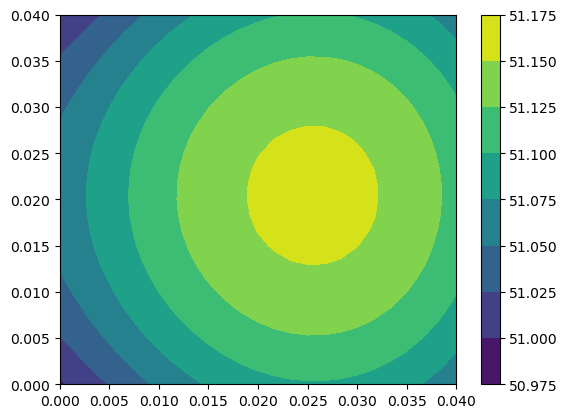

In [312]:
# plotting initial T distribution after solving
fig, ax = plt.subplots()
contour1 = ax.contourf(heq_init.X, heq_init.Y, heq_init.u - 273)
fig.colorbar(contour1, ax=ax)
plt.show()

In [ ]:
iter_x_jax_scaling = []

iter_maxT_jax_scaling = []
iter_eta_jax_scaling = []

iter_obj_jax_scaling = []
iter_grad_obj_jax_scaling = []

iter_constr_jax_scaling = []
iter_grad_constr_jax_scaling = []

iter_grad_L_jax_scaling = []
# iter_grad_norm_jax = []


def opt_iter_callback_jax_scaling(zk, state=None):
    """Called by trust-constr once per iteration with current xk."""
    print(f'\n{state.nit}-th iteration callback ...')
    xk = z_to_x_jax(zk)
    v = xk[0]
    a = xk[1]
    b = xk[2]
    c = xk[3]
    fk = state.fun
    eta = -0.002 * v**2 + 0.08 * v
    maxT = 350.0 * 5 * (state.fun + 0.8 * eta) # since obj = w1*maxT/T_ref - w2*eta
    constr = c_jax_wrapped(zk)*10

    iter_x_jax_scaling.append(np.array(xk, copy=True))
    iter_obj_jax_scaling.append(fk)
    iter_eta_jax_scaling.append(eta)
    iter_maxT_jax_scaling.append(maxT)  
    iter_constr_jax_scaling.append(constr)
    iter_grad_obj_jax_scaling.append(state.grad.copy())
    # iter_grad_constr.append([jac.copy() for jac in state.jac])
    iter_grad_L_jax_scaling.append(state.lagrangian_grad)

    print(f'Current x: {xk}')
    print(f'Current objective: {fk}')
    print(f'Current maxT: {maxT}')
    print(f'Current eta: {eta}')
    print(f'Current constraint value: {constr}')
    print(f'gradient of objective: {state.grad}')
    # print(f'gradient of constraints: {[jac for jac in state.jac]}')
    print(f'gradient of Lagrangian: {state.lagrangian_grad}')
    print()

In [ ]:
v0 = 10.0
a0 = 1e5
b0 = 1e5
c0 = (1.5625*10**5 - 0.02*b0 - 0.02*a0)  # same formula as before
x0 = np.array([v0, a0, b0, c0])

# ---- Bounds for inputs ----
bounds = [
    (0.0, 30.0),        # v
    (-np.inf, np.inf),  # a
    (-np.inf, np.inf),  # b
    (0.0, np.inf),      # c
]

# Using NonlinearConstraint from scipy
constraints = [{'type': 'eq', 'fun': c_jax_wrapped, 'jac': grad_c_wrapped}]

# --- Optimization with automatic differentiation ---
sci_opt.minimize(fun=f_jax_wrapped, x0=x0, method='trust-constr', jac=grad_f_wrapped, bounds=bounds, constraints=constraints, tol=1e-6, callback=opt_iter_callback_jax)

objective function starts to be evaluated (JAX)

1-th iteration callback ...
Current x: [1.0000e+01 1.0000e+05 1.0000e+05 1.5225e+05]
Current objective: 64.32820892333984
Current maxT: 324.04104461669925
Current eta: 0.6000000000000001
Current constraint value: 0.0
gradient of objective: [-5.77960797e-02  2.45955022e-07  2.45491037e-07  1.22732572e-05]
gradient of Lagrangian: [-6.07916814e-02  9.24015010e-09  8.77616569e-09 -3.60326388e-10]

objective function starts to be evaluated (JAX)


/home/chiyoung0/miniconda3/envs/general_purpose/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)



2-th iteration callback ...
Current x: [1.00310556e+01 1.00000000e+05 1.00000000e+05 1.52250000e+05]
Current objective: 64.32469177246094
Current maxT: 324.02842004136863
Current eta: 0.6012402947659905
Current constraint value: 0.0
gradient of objective: [-5.74804172e-02  2.44351497e-07  2.43886518e-07  1.21930379e-05]
gradient of Lagrangian: [-6.16740886e-02  1.36162744e-08  1.31512952e-08 -5.35351499e-10]


3-th iteration callback ...
Current x: [1.00310556e+01 1.00000000e+05 1.00000000e+05 1.52250000e+05]
Current objective: 64.32469177246094
Current maxT: 324.02842004136863
Current eta: 0.6012402947659905
Current constraint value: 0.0
gradient of objective: [-5.74804172e-02  2.44351497e-07  2.43886518e-07  1.21930379e-05]
gradient of Lagrangian: [-5.77538678e-02  3.11564161e-09  2.65066245e-09 -1.15326104e-10]

objective function starts to be evaluated (JAX)

4-th iteration callback ...
Current x: [1.00889285e+01 1.00000000e+05 1.00000000e+05 1.52250000e+05]
Current objective: 64.